# Pengembangan Model Prediksi Water Stress Tanaman Menggunakan Clustering K-Means dan Random Forest



Pengembangan Model Prediksi Water Stress Tanaman
Menggunakan Window Analysis, K-Means Clustering,
dan Random Forest

Dataset:
High-resolution time series of leaf length and leaf thickness
of strawberry and tomato measured in a growth chamber



#Import Library

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib



#Memuat Dataset

**Load CSV**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/smt 4/raw-measurement-data(1).csv")

**Info Dataset**

In [4]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

(1186151, 53)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186151 entries, 0 to 1186150
Data columns (total 53 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1186151 non-null  int64  
 1   temp              1186151 non-null  float64
 2   rh                1186151 non-null  float64
 3   pd1               1186151 non-null  int64  
 4   pd2               1186151 non-null  int64  
 5   syl_channel_0     1186151 non-null  int64  
 6   syl_channel_8     1186151 non-null  int64  
 7   syl_channel_1     1186151 non-null  int64  
 8   syl_channel_9     1186151 non-null  int64  
 9   syl_channel_2     1186151 non-null  int64  
 10  syl_channel_10    1186151 non-null  int64  
 11  syl_channel_3     1186151 non-null  int64  
 12  syl_channel_11    1186151 non-null  int64  
 13  syl_channel_4     1186151 non-null  int64  
 14  syl_channel_12    1186151 non-null  int64  
 15  syl_channel_5     1186151 non-null 

np.int64(0)

**Time Series Preparation**

In [5]:
start_time = pd.Timestamp("2019-12-24 00:00:00")

df["timestamp"] = pd.date_range(
    start=start_time,
    periods=len(df),
    freq="s"
)

df.head()

,Unnamed: 0,temp,rh,pd1,pd2,syl_channel_0,syl_channel_8,syl_channel_1,syl_channel_9,syl_channel_2,...,pla_ref_2_ang,pla_sample_3_i,pla_sample_3_q,pla_sample_3_amp,pla_sample_3_ang,pla_ref_3_i,pla_ref_3_q,pla_ref_3_amp,pla_ref_3_ang,timestamp
0,0,23.307014,60.152590,15134,2990,12973,4737,11832,31858,11935,...,1.347268,319,1121,1165.505041,1.489994,5241,28177,28660.275819,1.536213,2019-12-24 00:00:00
1,1,23.333717,60.213627,15146,2993,12957,4737,11816,31859,11919,...,1.347240,317,1109,1153.416664,1.489271,5185,27881,28359.026535,1.536226,2019-12-24 00:00:01
2,2,23.307014,60.253300,15136,2991,12943,4737,11802,31859,11904,...,1.347240,317,1109,1153.416664,1.489271,5185,27881,28359.026535,1.536226,2019-12-24 00:00:02
3,3,23.320366,60.289920,15178,3001,12930,4737,11789,31859,11891,...,1.347236,317,1104,1148.610030,1.488534,5165,27775,28251.156613,1.536230,2019-12-24 00:00:03
4,4,23.320366,60.331120,15539,3100,12917,4737,11777,31859,11879,...,1.347236,317,1104,1148.610030,1.488534,5165,27775,28251.156613,1.536230,2019-12-24 00:00:04


#Window Analysis (1 Menit)

In [6]:
df = df.set_index("timestamp")
df_window = df.resample("1min").agg(
    ["mean","std","min","max"]
)

df_window.columns = [
    "_".join(col)
    for col in df_window.columns
]

df_window = df_window.reset_index()


In [7]:
print("="*60)
print("WINDOW ANALYSIS BERHASIL")
print("="*60)

print(f"Jumlah Data Awal     : {len(df):,}")
print(f"Jumlah Data Window   : {len(df_window):,}")
print(f"Jumlah Feature Baru  : {df_window.shape[1]}")

reduction = (1 - len(df_window)/len(df))*100
print(f"Reduksi Data         : {reduction:.2f}%")

WINDOW ANALYSIS BERHASIL
Jumlah Data Awal     : 1,186,151
Jumlah Data Window   : 19,770
Jumlah Feature Baru  : 213
Reduksi Data         : 98.33%


# Exploratory Data Analysis (EDA)



Tahapan ini bertujuan untuk memahami karakteristik data hasil Window Analysis sebelum dilakukan proses Feature Engineering dan Clustering.

Analisis meliputi:

- Distribusi data setiap sensor utama
- Perubahan data terhadap waktu
- Korelasi antar feature
- Deteksi outlier
- Analisis pengaruh penyiraman terhadap kondisi sensor

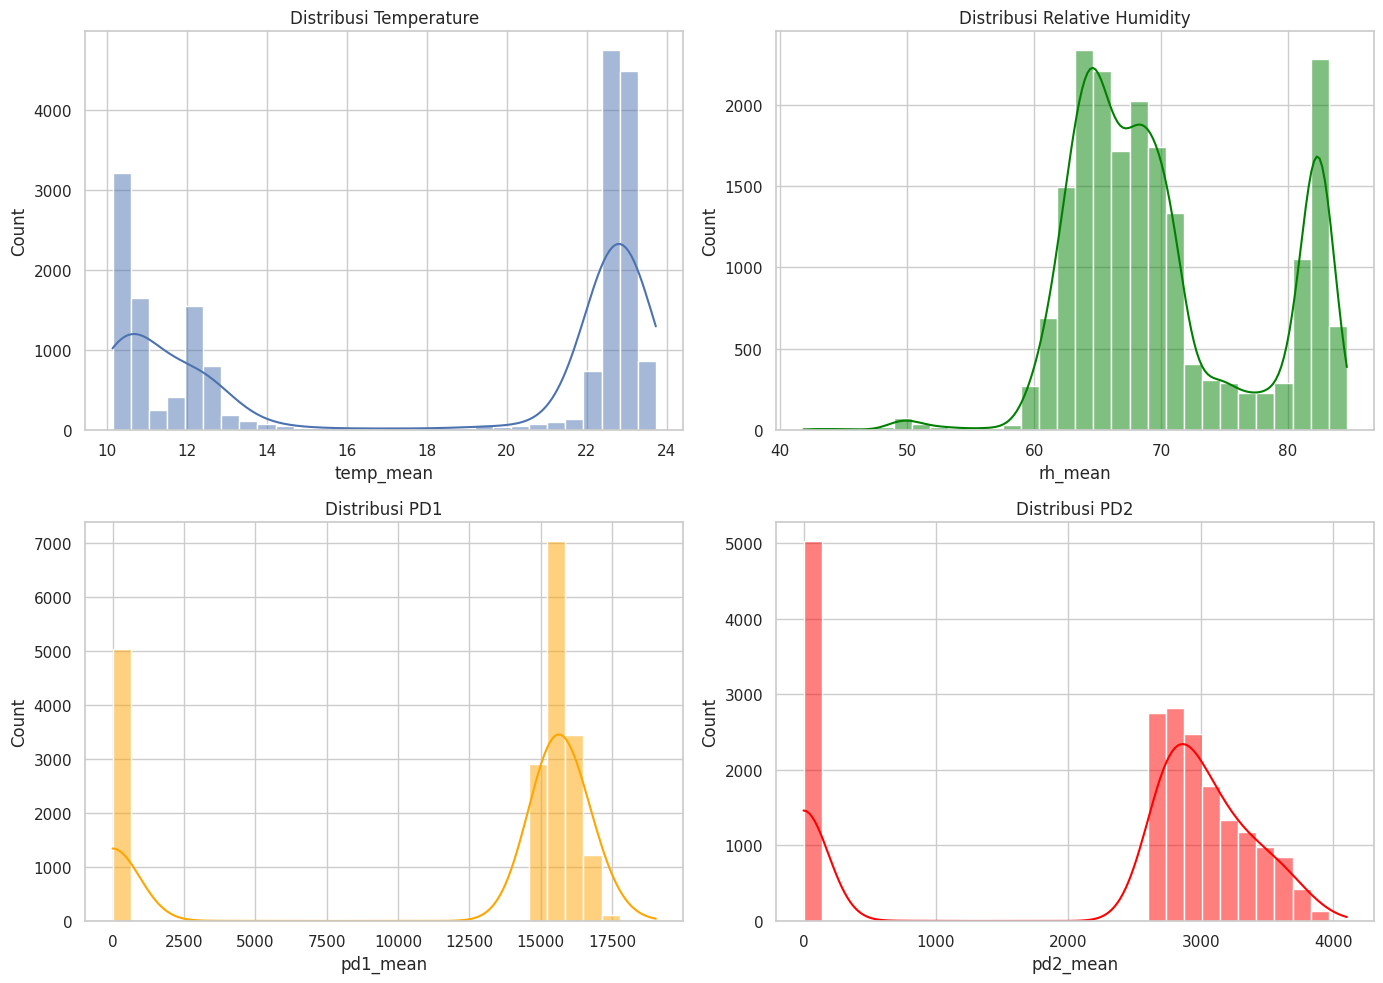

In [8]:
# ==========================================
# Distribusi Feature Sensor
# ==========================================

fig, ax = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(
    df_window["temp_mean"],
    bins=30,
    kde=True,
    ax=ax[0,0]
)
ax[0,0].set_title("Distribusi Temperature")

sns.histplot(
    df_window["rh_mean"],
    bins=30,
    kde=True,
    color="green",
    ax=ax[0,1]
)
ax[0,1].set_title("Distribusi Relative Humidity")

sns.histplot(
    df_window["pd1_mean"],
    bins=30,
    kde=True,
    color="orange",
    ax=ax[1,0]
)
ax[1,0].set_title("Distribusi PD1")

sns.histplot(
    df_window["pd2_mean"],
    bins=30,
    kde=True,
    color="red",
    ax=ax[1,1]
)
ax[1,1].set_title("Distribusi PD2")

plt.tight_layout()
plt.show()

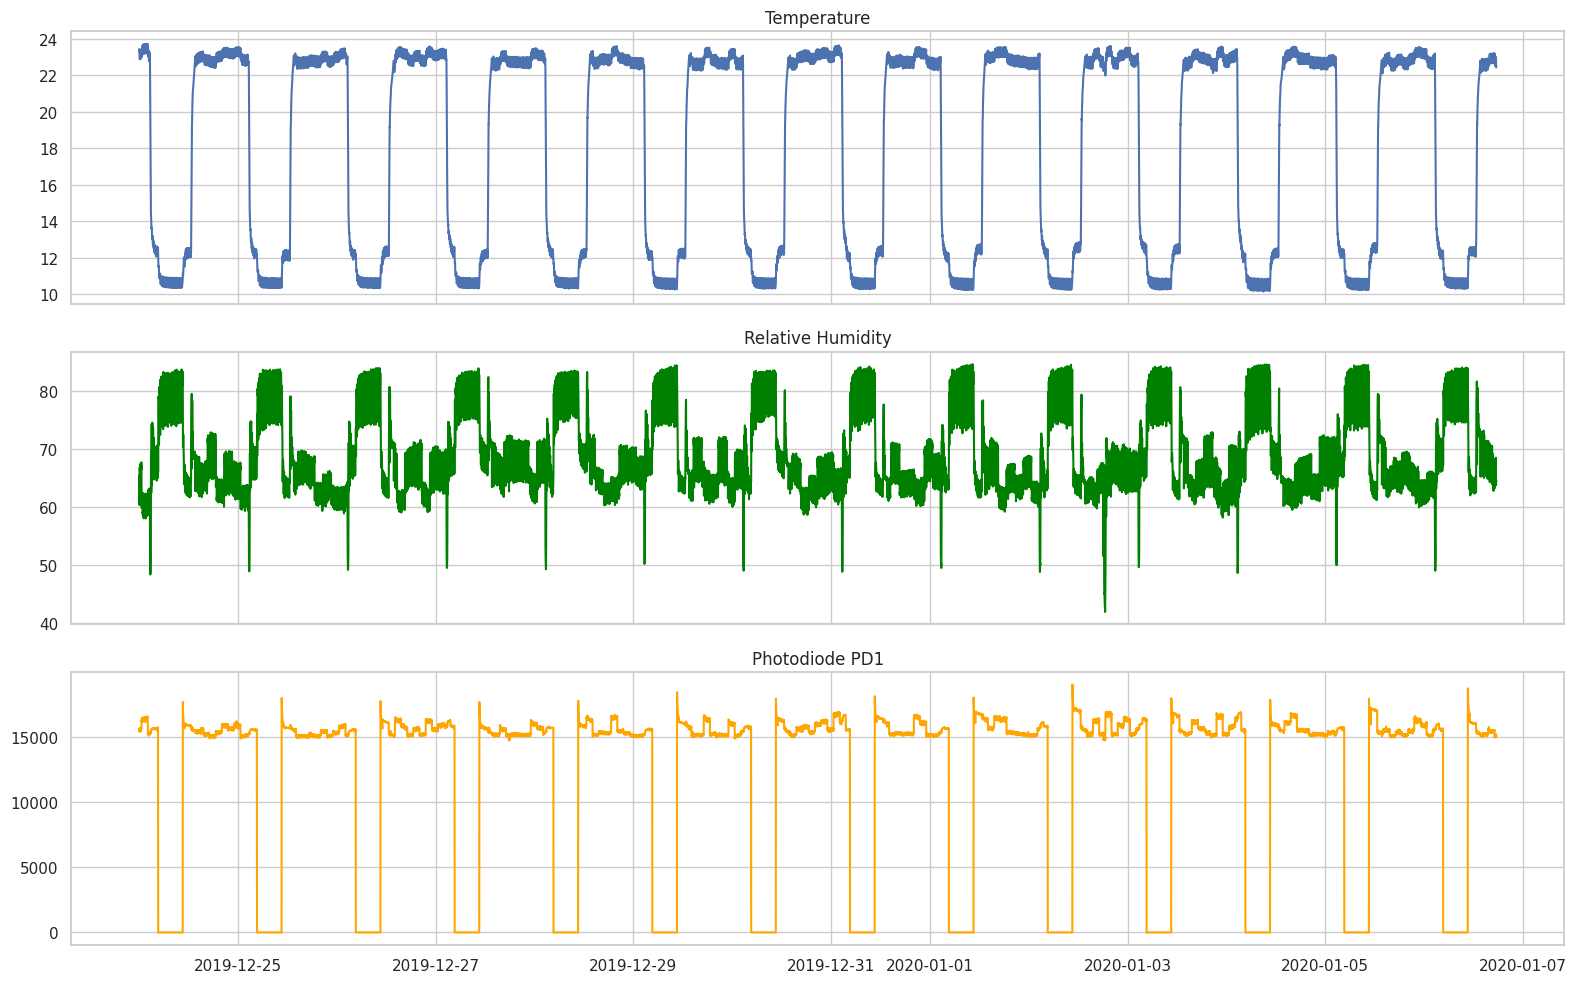

In [9]:
# ==========================================
# Perubahan Sensor Terhadap Waktu
# ==========================================

fig, ax = plt.subplots(3,1, figsize=(16,10), sharex=True)

ax[0].plot(df_window["timestamp"], df_window["temp_mean"])
ax[0].set_title("Temperature")

ax[1].plot(df_window["timestamp"], df_window["rh_mean"], color="green")
ax[1].set_title("Relative Humidity")

ax[2].plot(df_window["timestamp"], df_window["pd1_mean"], color="orange")
ax[2].set_title("Photodiode PD1")

plt.tight_layout()
plt.show()

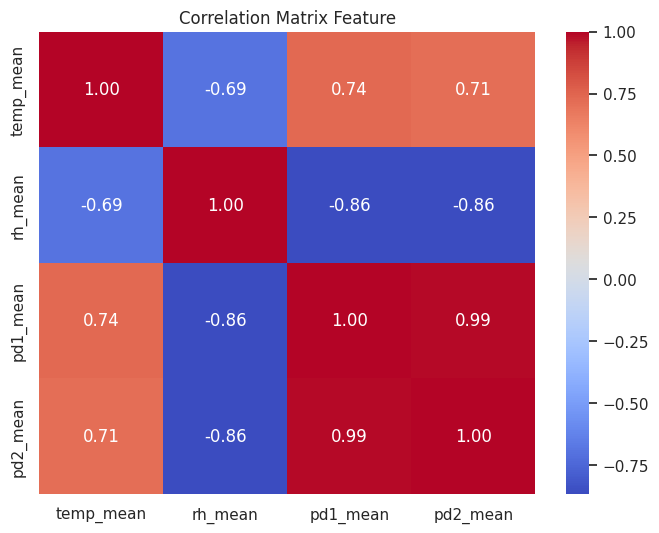

In [10]:
# Korelasi Antar Feature
selected = [
    "temp_mean",
    "rh_mean",
    "pd1_mean",
    "pd2_mean"
]

corr = df_window[selected].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Feature")
plt.show()

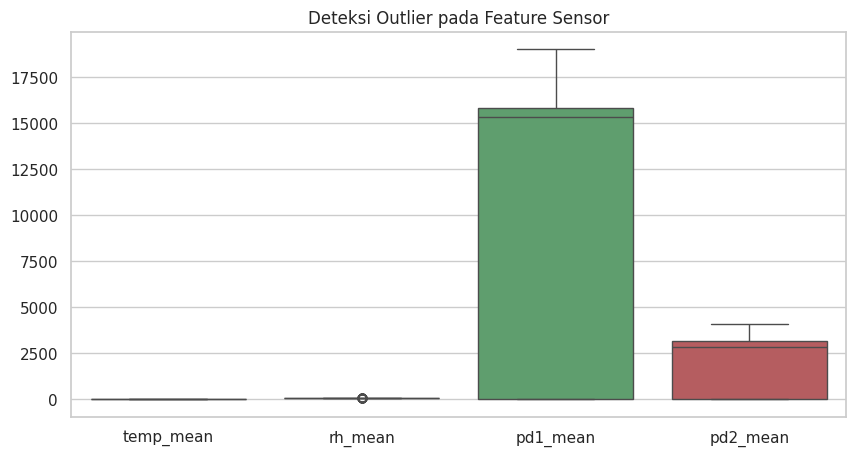

In [11]:
# Deteksi Outlier

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_window[
        [
            "temp_mean",
            "rh_mean",
            "pd1_mean",
            "pd2_mean"
        ]
    ]
)

plt.title("Deteksi Outlier pada Feature Sensor")
plt.show()

**Analisis Pengaruh Penyiraman**

Dataset berasal dari eksperimen penyiraman tanaman.

Visualisasi berikut menunjukkan perubahan nilai sensor sebelum, selama, dan setelah proses penyiraman sehingga dapat diamati respon masing-masing sensor terhadap perubahan kadar air tanaman.

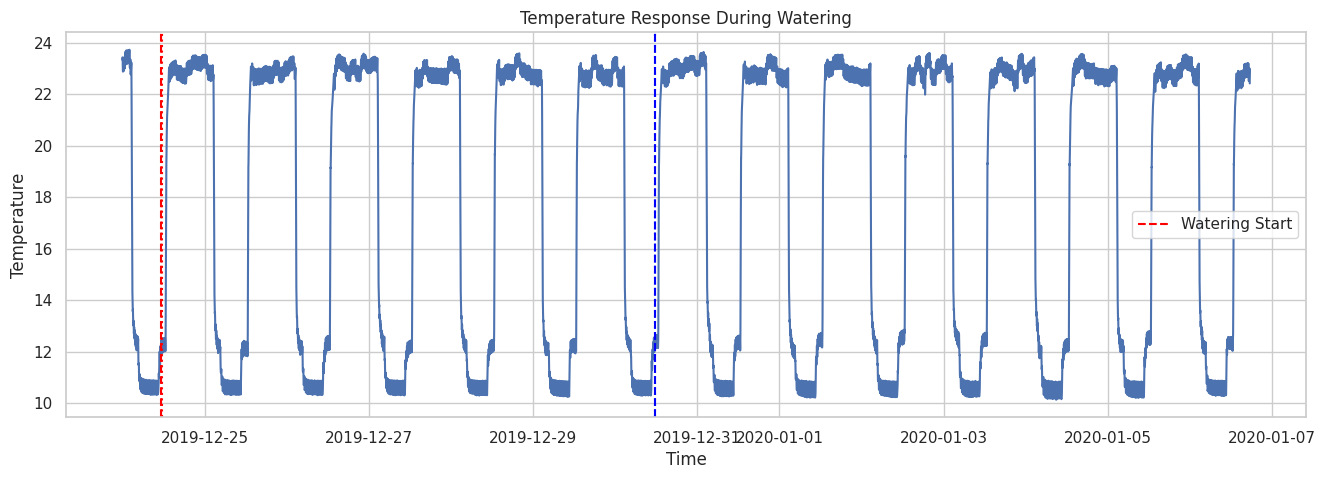

In [12]:
# Pengaruh Penyiraman terhadap Temperature
plt.figure(figsize=(16,5))

plt.plot(
    df_window["timestamp"],
    df_window["temp_mean"]
)

plt.axvline(
    pd.Timestamp("2019-12-24 11:12"),
    color="red",
    linestyle="--",
    label="Watering Start"
)

plt.axvline(
    pd.Timestamp("2019-12-24 11:25"),
    color="red",
    linestyle=":"
)

plt.axvline(
    pd.Timestamp("2019-12-30 11:30"),
    color="blue",
    linestyle="--"
)

plt.axvline(
    pd.Timestamp("2019-12-30 11:45"),
    color="blue",
    linestyle=":"
)

plt.title("Temperature Response During Watering")

plt.xlabel("Time")
plt.ylabel("Temperature")

plt.legend()

plt.show()

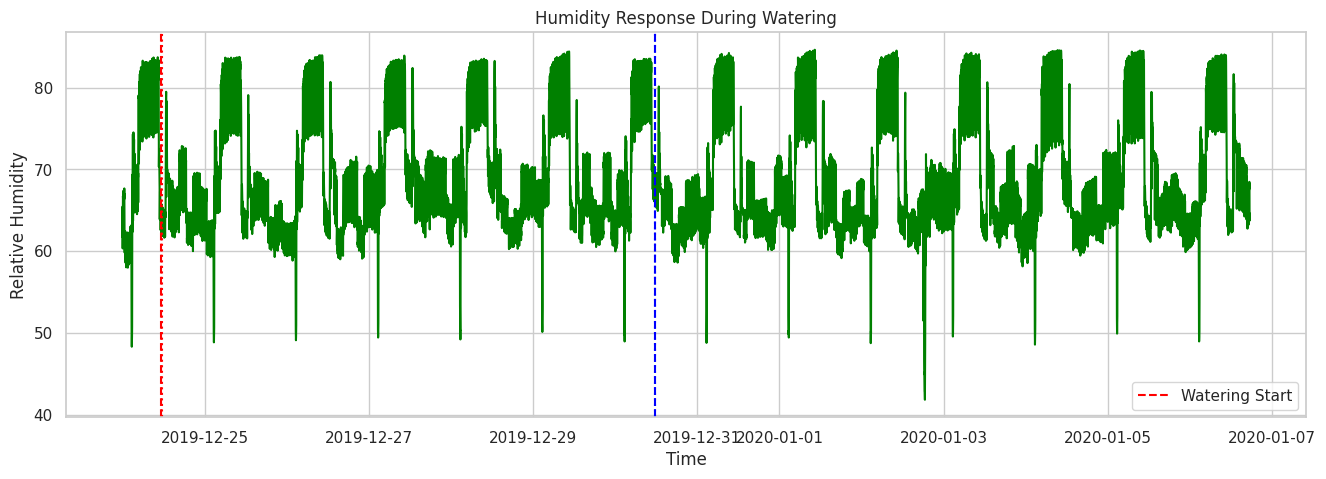

In [13]:
# Pengaruh Penyiraman terhadap Humidity

plt.figure(figsize=(16,5))

plt.plot(
    df_window["timestamp"],
    df_window["rh_mean"],
    color="green"
)

plt.axvline(pd.Timestamp("2019-12-24 11:12"), color="red", linestyle="--", label="Watering Start")
plt.axvline(pd.Timestamp("2019-12-24 11:25"), color="red", linestyle=":")
plt.axvline(pd.Timestamp("2019-12-30 11:30"), color="blue", linestyle="--")
plt.axvline(pd.Timestamp("2019-12-30 11:45"), color="blue", linestyle=":")

plt.title("Humidity Response During Watering")

plt.xlabel("Time")
plt.ylabel("Relative Humidity")

plt.legend()

plt.show()

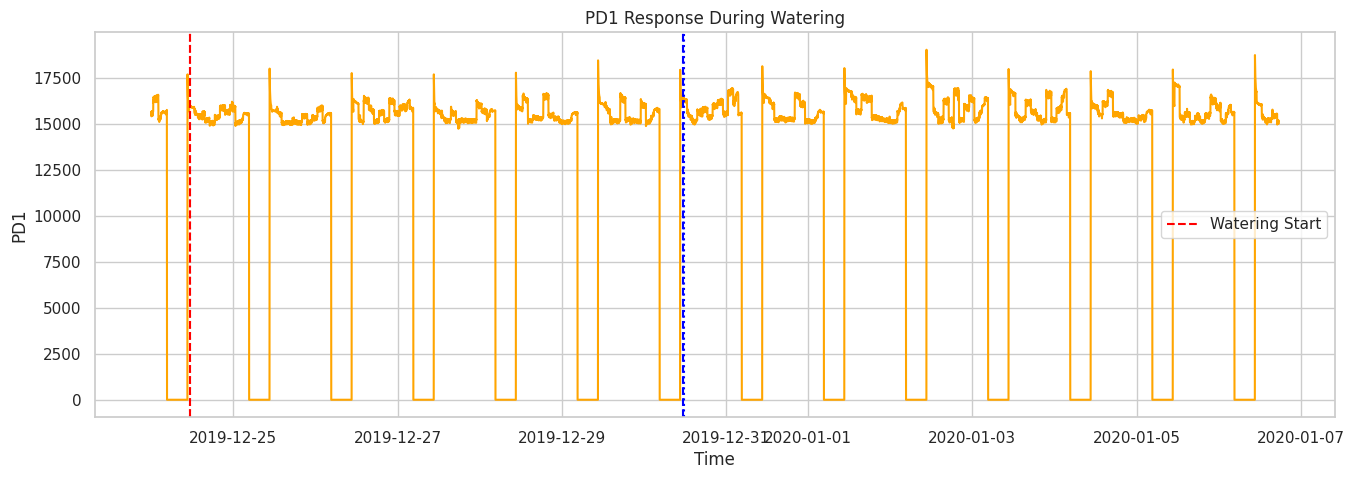

In [14]:
# Pengaruh Penyiraman terhadap PD1

plt.figure(figsize=(16,5))

plt.plot(
    df_window["timestamp"],
    df_window["pd1_mean"],
    color="orange"
)

plt.axvline(pd.Timestamp("2019-12-24 11:12"), color="red", linestyle="--", label="Watering Start")
plt.axvline(pd.Timestamp("2019-12-24 11:25"), color="red", linestyle=":")
plt.axvline(pd.Timestamp("2019-12-30 11:30"), color="blue", linestyle="--")
plt.axvline(pd.Timestamp("2019-12-30 11:45"), color="blue", linestyle=":")

plt.title("PD1 Response During Watering")

plt.xlabel("Time")
plt.ylabel("PD1")

plt.legend()

plt.show()

# Feature Engineering

Tahapan Feature Engineering bertujuan untuk membangun atribut baru yang lebih representatif dibandingkan data sensor mentah.

Feature yang dibuat berasal dari:

- Ringkasan sensor spektral (SYL)
- Ringkasan amplitudo PLA
- Selisih amplitudo PLA
- Interaksi suhu dan kelembaban
- Rentang perubahan sensor
- Perbedaan nilai photodiode

Feature-feature ini nantinya digunakan sebagai masukan utama pada proses Clustering dan Machine Learning.

In [15]:

# Menentukan Kelompok Feature Sensor

df_feature = df_window.copy()

# Spectral Sensor (SYL)
syl_cols = [
    col for col in df_feature.columns
    if "syl_channel" in col and "_mean" in col
]

# PLA Sample Amplitude
pla_sample_amp = [
    col for col in df_feature.columns
    if "pla_sample" in col and "_amp_mean" in col
]

# PLA Reference Amplitude
pla_ref_amp = [
    col for col in df_feature.columns
    if "pla_ref" in col and "_amp_mean" in col
]

print(f"Jumlah Spectral Feature : {len(syl_cols)}")
print(f"Jumlah PLA Sample       : {len(pla_sample_amp)}")
print(f"Jumlah PLA Reference    : {len(pla_ref_amp)}")

Jumlah Spectral Feature : 16
Jumlah PLA Sample       : 4
Jumlah PLA Reference    : 4


In [16]:
# Membuat Feature Engineering

# Spectral Feature

df_feature["spectral_mean"] = df_feature[syl_cols].mean(axis=1)
df_feature["spectral_std"] = df_feature[syl_cols].std(axis=1)
df_feature["spectral_max"] = df_feature[syl_cols].max(axis=1)
df_feature["spectral_min"] = df_feature[syl_cols].min(axis=1)

# PLA Feature

df_feature["pla_sample_mean"] = df_feature[pla_sample_amp].mean(axis=1)
df_feature["pla_ref_mean"] = df_feature[pla_ref_amp].mean(axis=1)
df_feature["pla_difference"] = (
    df_feature["pla_sample_mean"]
    - df_feature["pla_ref_mean"]
)

# Environmental Feature
df_feature["temp_rh_index"] = (
    df_feature["temp_mean"]
    * df_feature["rh_mean"]
)
df_feature["temp_range"] = (
    df_feature["temp_max"]
    - df_feature["temp_min"]
)
df_feature["rh_range"] = (
    df_feature["rh_max"]
    - df_feature["rh_min"]
)
df_feature["pd_difference"] = (
    df_feature["pd1_mean"]
    - df_feature["pd2_mean"]
)
print("Feature Engineering berhasil dilakukan.")

Feature Engineering berhasil dilakukan.


In [17]:

# Ringkasan Feature Engineering


new_features = [
    "spectral_mean",
    "spectral_std",
    "spectral_max",
    "spectral_min",
    "pla_sample_mean",
    "pla_ref_mean",
    "pla_difference",
    "temp_rh_index",
    "temp_range",
    "rh_range",
    "pd_difference",
]

summary = pd.DataFrame({
    "Feature Baru": new_features,
    "Deskripsi": [
        "Rata-rata sensor spektral",
        "Standar deviasi sensor spektral",
        "Nilai maksimum spektral",
        "Nilai minimum spektral",
        "Rata-rata amplitudo PLA Sample",
        "Rata-rata amplitudo PLA Reference",
        "Selisih amplitudo PLA",
        "Indeks interaksi suhu × kelembaban",
        "Rentang perubahan suhu",
        "Rentang perubahan kelembaban",
        "Selisih PD1 dan PD2"
    ]
})

display(summary)

print(f"Total Feature Baru : {len(new_features)}")

,Feature Baru,Deskripsi
0,spectral_mean,Rata-rata sensor spektral
1,spectral_std,Standar deviasi sensor spektral
2,spectral_max,Nilai maksimum spektral
3,spectral_min,Nilai minimum spektral
4,pla_sample_mean,Rata-rata amplitudo PLA Sample
5,pla_ref_mean,Rata-rata amplitudo PLA Reference
6,pla_difference,Selisih amplitudo PLA
7,temp_rh_index,Indeks interaksi suhu × kelembaban
8,temp_range,Rentang perubahan suhu
9,rh_range,Rentang perubahan kelembaban


Total Feature Baru : 11


#Exploratory Data Analysis untuk Feature Baru

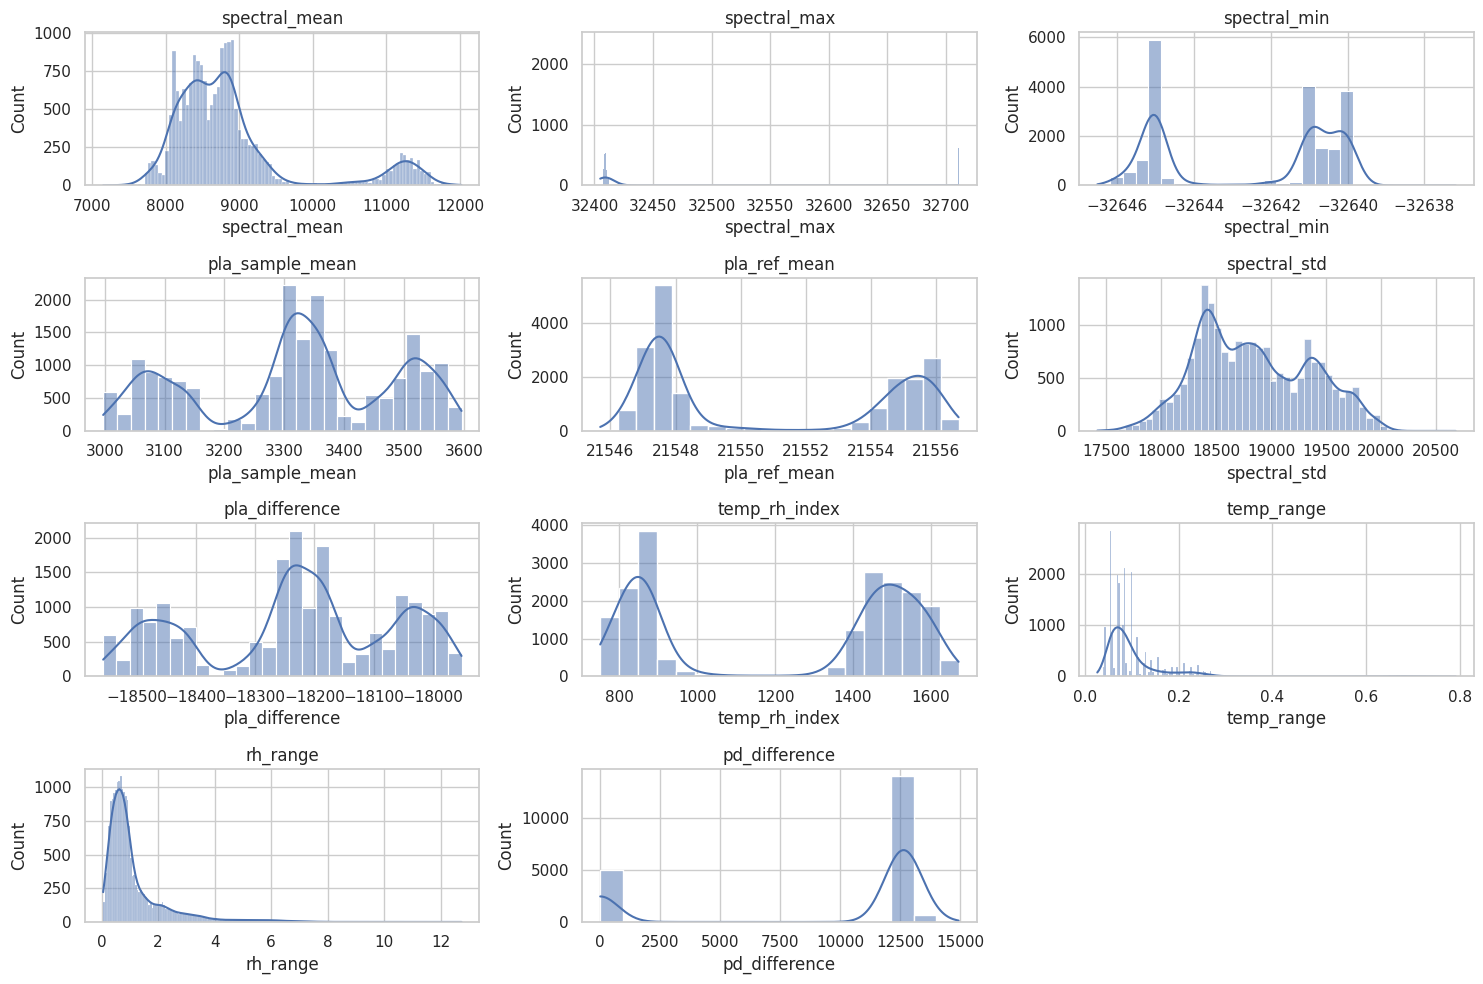

In [19]:
feature_visual = [
    "spectral_mean",
    "spectral_max",
    "spectral_min",
    "pla_sample_mean",
    "pla_ref_mean",
    "spectral_std",
    "pla_difference",
    "temp_rh_index",
    "temp_range",
    "rh_range",
    "pd_difference"
]

fig, axes = plt.subplots(4, 3, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(feature_visual):
    sns.histplot(
        data=df_feature,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Hapus subplot kosong
for j in range(len(feature_visual), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 6. Feature Selection & Data Preprocessing

Tahapan ini bertujuan untuk memperoleh feature yang paling representatif sebelum dilakukan proses clustering.

Tahapan meliputi:

- Menentukan feature awal
- Menghapus feature yang memiliki korelasi sangat tinggi
- Menghapus feature dengan variansi rendah
- Melakukan standardisasi data
- Mereduksi dimensi menggunakan PCA

In [20]:

# Menentukan Feature yang Digunakan


selected_features = [
    "temp_mean",
    "rh_mean",
    "pd1_mean",
    "pd2_mean",
    "spectral_mean",
    "spectral_std",
    "pla_difference",
    "temp_rh_index",
    "temp_range",
    "rh_range"
]
X = df_feature[selected_features].copy()
print(f"Jumlah Data    : {X.shape[0]}")
print(f"Jumlah Feature : {X.shape[1]}")

Jumlah Data    : 19770
Jumlah Feature : 10


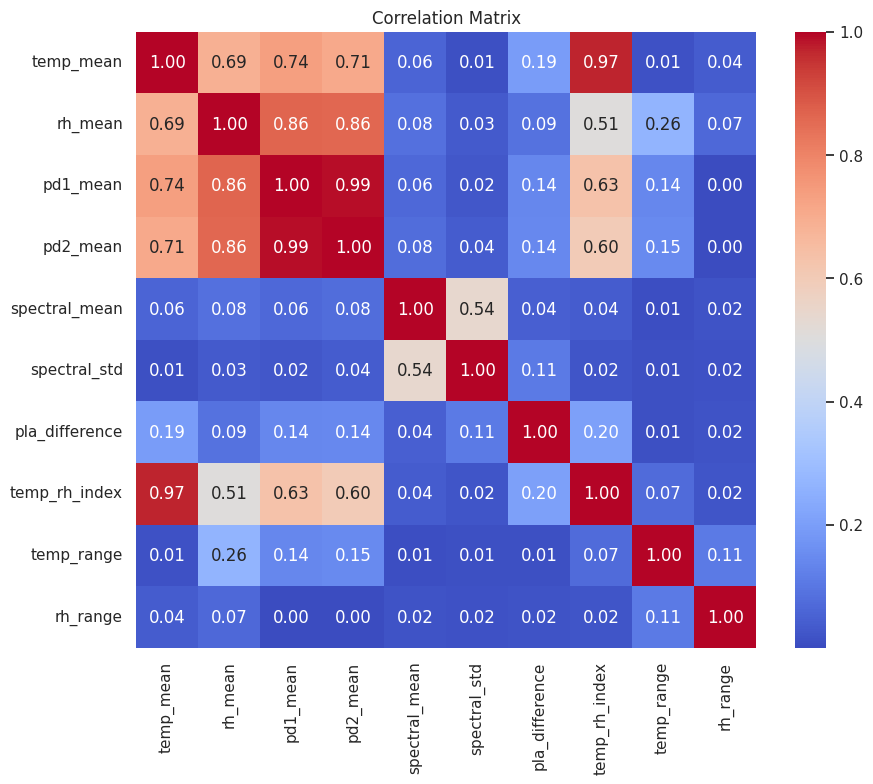

Feature yang dihapus : ['pd2_mean', 'temp_rh_index']


In [21]:

# Correlation Analysis


corr_matrix = X.corr().abs()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]
print("Feature yang dihapus :", to_drop)

In [22]:

# Variance Threshold


X_filtered = X.drop(columns=to_drop)
selector = VarianceThreshold(
    threshold=0.01
)
X_variance = selector.fit_transform(X_filtered)
selected_columns = X_filtered.columns[
    selector.get_support()
]
X_selected = pd.DataFrame(
    X_variance,
    columns=selected_columns
)
print(f"Sebelum Seleksi : {X.shape[1]} feature")
print(f"Sesudah Seleksi : {X_selected.shape[1]} feature")
print("\nFeature Terpilih:")
print(list(X_selected.columns))

Sebelum Seleksi : 10 feature
Sesudah Seleksi : 7 feature

Feature Terpilih:
['temp_mean', 'rh_mean', 'pd1_mean', 'spectral_mean', 'spectral_std', 'pla_difference', 'rh_range']


## Data Preprocessing

Feature hasil seleksi kemudian dilakukan proses standardisasi agar seluruh feature memiliki skala yang sama.

Selanjutnya dilakukan Principal Component Analysis (PCA) untuk mereduksi dimensi data sebelum proses clustering.

In [23]:
# StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_selected.columns
)
print("Standardisasi selesai.")
display(
    X_scaled.describe().round(2)
)

Standardisasi selesai.


,temp_mean,rh_mean,pd1_mean,spectral_mean,spectral_std,pla_difference,rh_range
count,19770.00,19770.00,19770.00,19770.00,19770.00,19770.00,19770.00
mean,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.36,-3.82,-1.71,-1.92,-2.75,-1.94,-0.95
25%,-1.17,-0.74,-1.71,-0.60,-0.80,-1.00,-0.57
50%,0.79,-0.26,0.53,-0.23,-0.12,0.05,-0.33
75%,0.88,0.65,0.60,0.09,0.86,0.85,0.12
max,1.03,1.96,1.07,3.40,3.57,1.68,10.00


In [24]:

# Principal Component Analysis

pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

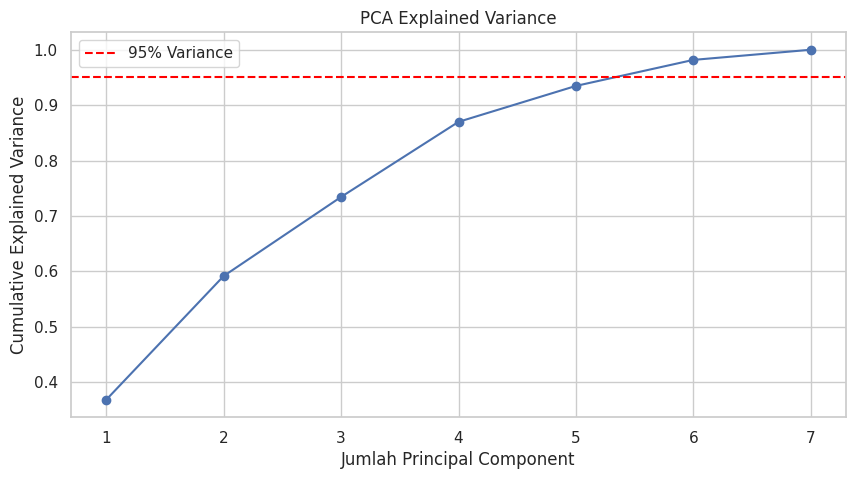

In [26]:

# Explained Variance PCA

plt.figure(figsize=(10,5))
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)
plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95% Variance"
)
plt.xlabel("Jumlah Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.legend()
plt.show()

In [27]:

# Transform PCA


pca = PCA(
    n_components=0.95,
    random_state=42
)
X_pca = pca.fit_transform(X_scaled)
print(f"Feature Sebelum PCA : {X_scaled.shape[1]}")
print(f"Feature Setelah PCA : {X_pca.shape[1]}")
print(
    f"Explained Variance : {pca.explained_variance_ratio_.sum()*100:.2f}%"
)

Feature Sebelum PCA : 7
Feature Setelah PCA : 6
Explained Variance : 98.17%


# Menentukan Jumlah Cluster Optimal

Sebelum menerapkan algoritma K-Means, diperlukan penentuan jumlah cluster (K) yang paling sesuai.

Pada penelitian ini digunakan dua metode evaluasi, yaitu:

- Elbow Method
- Silhouette Score

Hasil kedua metode dibandingkan untuk memperoleh jumlah cluster terbaik.

In [28]:
# Menghitung Nilai Inertia

from sklearn.cluster import KMeans
k_range = range(2, 11)
inertia = []
for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_pca)
    inertia.append(model.inertia_)

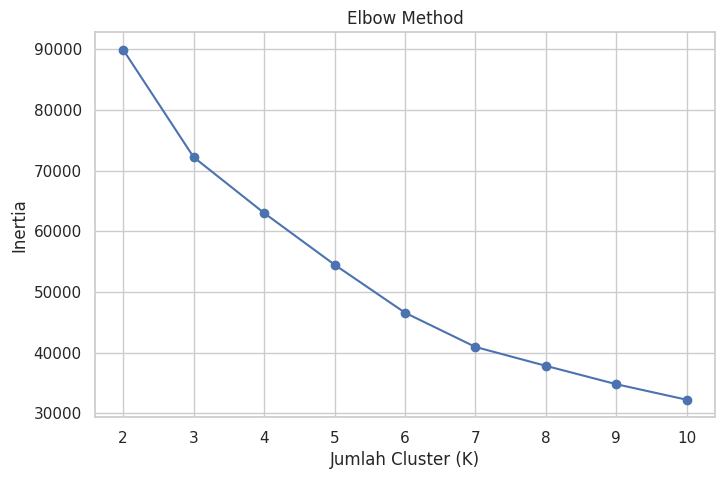

In [29]:
# Elbow Method
plt.figure(figsize=(8,5))
plt.plot(
    k_range,
    inertia,
    marker="o"
)
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [31]:
# Silhouette Score

from sklearn.metrics import silhouette_score
silhouette_scores =  []
for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_pca)
    score = silhouette_score(
        X_pca,
        labels
    )
    silhouette_scores.append(score)

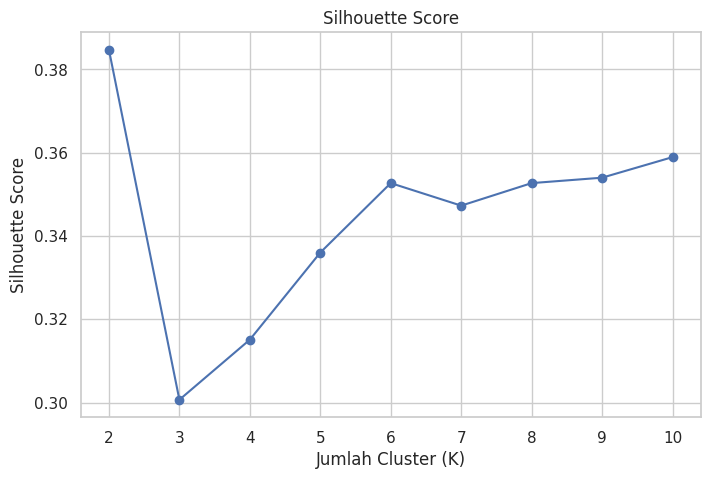

In [32]:
# Visualisasi Silhouette Score

plt.figure(figsize=(8,5))
plt.plot(
    k_range,
    silhouette_scores,
    marker="o"
)
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(True)
plt.show()

In [35]:
# Ringkasan Evaluasi Cluster

evaluation_df = pd.DataFrame({
    "Jumlah Cluster": list(k_range),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})
display(evaluation_df)
best_k = evaluation_df.loc[
    evaluation_df["Silhouette Score"].idxmax(),
    "Jumlah Cluster"
]
best_score = evaluation_df["Silhouette Score"].max()
print("="*60)
print(f"Jumlah Cluster Terbaik (Silhouette): {best_k}")
print(f"Silhouette Score : {best_score:.4f}")
print("="*60)

,Jumlah Cluster,Inertia,Silhouette Score
0,2,89904.843431,0.384724
1,3,72210.613400,0.300667
2,4,63014.153308,0.315094
3,5,54503.233504,0.336014
4,6,46587.477668,0.352697
5,7,40947.882136,0.347284
6,8,37835.652602,0.352697
7,9,34809.707608,0.353998
8,10,32251.138233,0.358937


Jumlah Cluster Terbaik (Silhouette): 2
Silhouette Score : 0.3847


Kesimpulan Analisis
Secara matematis, Silhouette tertinggi memang ada di K=2 (0.384).
Tetapi secara tujuan penelitian, kita ingin membangun kategori Water Stress.

Jika memakai K=2, hasilnya hanya:
Cluster 0 = Sehat
Cluster 1 = Stres

Padahal untuk sistem pendukung keputusan, lebih masuk akal memiliki:
🟢 Optimal
🟡 Moderate Stress
🔴 High Stress
Karena itu saya merekomendasikan K = 3.

Alasannya:
Masih didukung oleh Elbow Method.
Silhouette masih cukup baik (0.300).
Interpretasi biologis lebih masuk akal.
Cocok untuk membangun pseudo-label Water Stress.
Memudahkan implementasi di aplikasi web.

# K-Means Clustering

Pada tahap ini dilakukan proses pengelompokan data menggunakan algoritma **K-Means**. Jumlah cluster yang digunakan adalah **K = 3**, berdasarkan hasil evaluasi Elbow Method dan pertimbangan interpretasi domain mengenai tingkat kondisi tanaman.

Tahapan pada bagian ini meliputi:

- Melatih model K-Means
- Menambahkan label cluster ke dataset
- Menganalisis distribusi cluster
- Memvisualisasikan cluster menggunakan PCA
- Menganalisis karakteristik setiap cluster

In [36]:
# Menjalankan Algoritma K-Means Clustering
from sklearn.cluster import KMeans

# Jumlah cluster terbaik
k_optimal = 3

# Membangun model
kmeans = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=10
)

# Training model
cluster_labels = kmeans.fit_predict(X_scaled)

# Menambahkan hasil cluster ke dataset
df_cluster = df_feature.copy()
df_cluster["Cluster"] = cluster_labels

print("="*60)
print("K-MEANS BERHASIL DIJALANKAN")
print("="*60)
print(f"Jumlah Cluster : {k_optimal}")
print(f"Jumlah Data    : {len(df_cluster)}")

K-MEANS BERHASIL DIJALANKAN
Jumlah Cluster : 3
Jumlah Data    : 19770


,count
Cluster,
0,5050
1,6446
2,8274


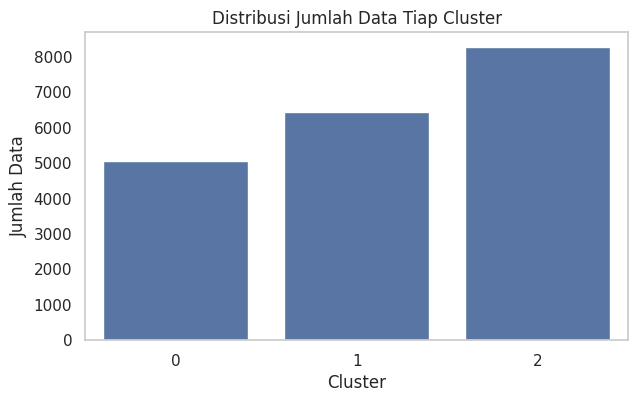

In [37]:
# Distribusi Data pada Setiap Cluster

cluster_count = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
)
display(cluster_count)
plt.figure(figsize=(7,4))
sns.barplot(
    x=cluster_count.index,
    y=cluster_count.values
)
plt.title("Distribusi Jumlah Data Tiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.grid(axis="y")
plt.show()

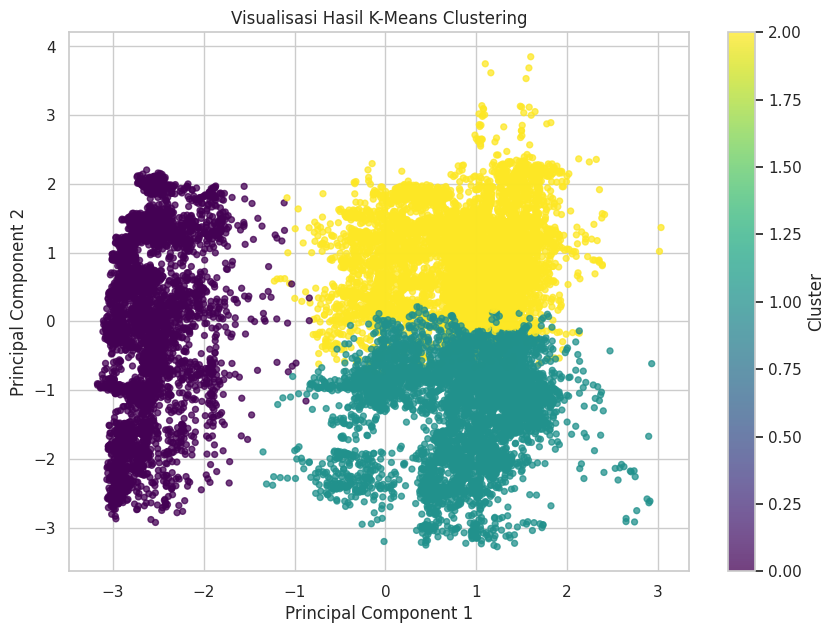

In [42]:
from sklearn.decomposition import PCA

# Visualisasi Cluster Menggunakan PCA
# ==========================================================
plt.figure(figsize=(10,7))

# Convert X_pca to a DataFrame to allow column indexing
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=df_cluster["Cluster"],
    cmap="viridis",
    s=18,
    alpha=0.75
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Visualisasi Hasil K-Means Clustering")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [39]:
# Ringkasan Karakteristik Setiap Cluster

cluster_summary = (
    df_cluster
    .groupby("Cluster")
    [
        [
            "temp_mean",
            "rh_mean",
            "pd1_mean",
            "pd2_mean",
            "spectral_mean",
            "spectral_std",
            "pla_difference",
            "temp_rh_index",
            "temp_range",
            "rh_range"
        ]
    ]
    .mean()
    .round(3)
)
print("="*60)
print("RINGKASAN KARAKTERISTIK SETIAP CLUSTER")
print("="*60)
display(cluster_summary)

RINGKASAN KARAKTERISTIK SETIAP CLUSTER


,temp_mean,rh_mean,pd1_mean,pd2_mean,spectral_mean,spectral_std,pla_difference,temp_rh_index,temp_range,rh_range
Cluster,,,,,,,,,,
0,10.549,81.043,45.036,8.567,8998.644,18822.464,-18270.860,854.618,0.086,1.160
1,20.600,66.692,15660.355,3016.213,9553.033,18435.154,-18117.616,1371.592,0.110,1.184
2,20.217,66.076,15730.671,3074.645,8350.077,19162.363,-18297.483,1333.762,0.114,1.134


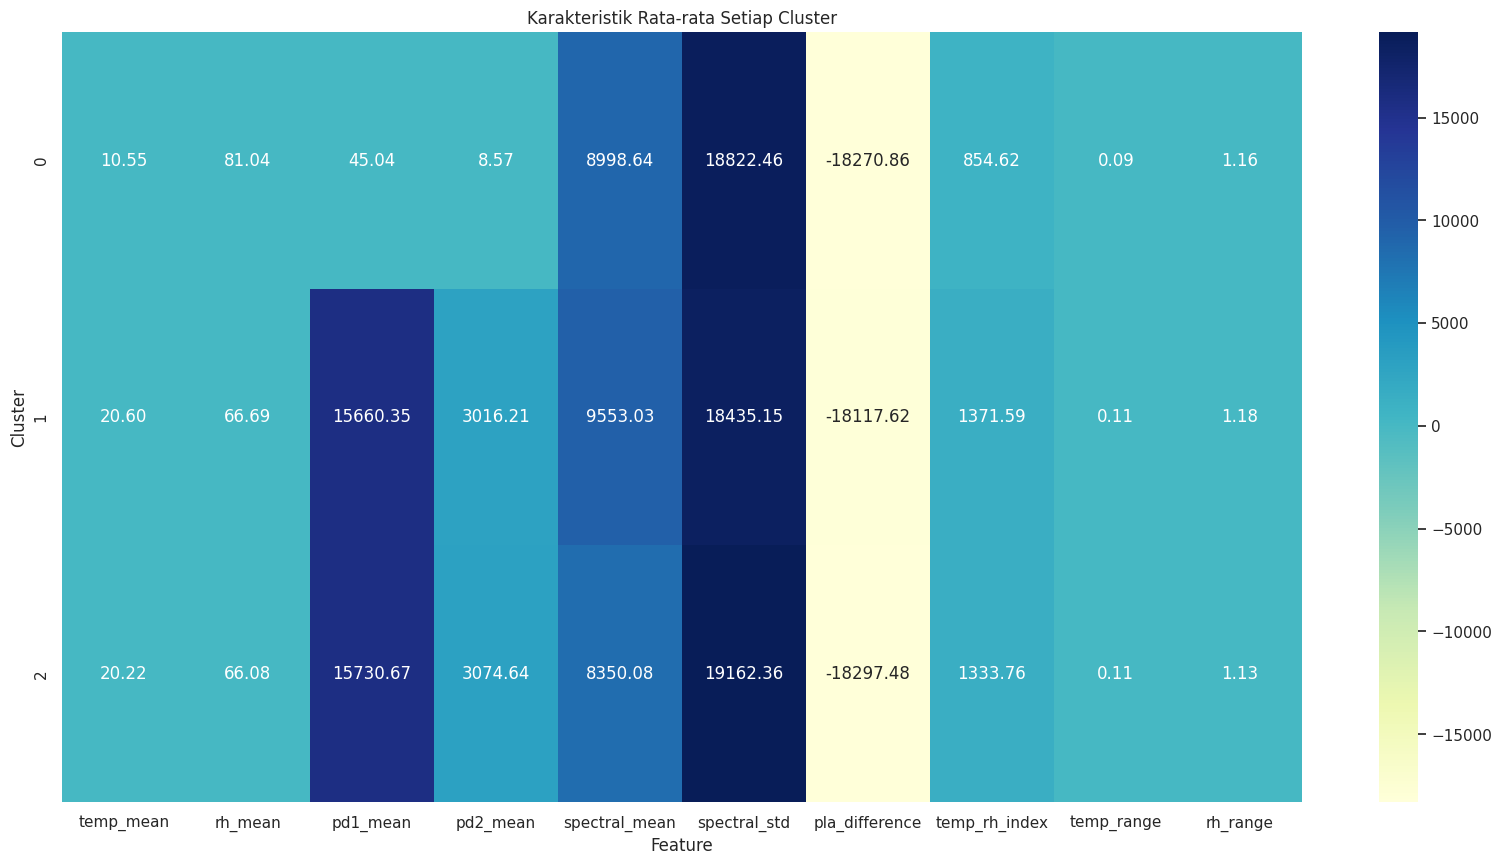

In [41]:

# Heatmap Karakteristik Tiap Cluster
plt.figure(figsize=(20,10))
sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)
plt.title("Karakteristik Rata-rata Setiap Cluster")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.show()

# Analisis Mendalam Hasil Clustering

Setelah proses clustering selesai dilakukan, tahap berikutnya adalah menganalisis karakteristik dari setiap cluster yang terbentuk.

Analisis dilakukan melalui beberapa pendekatan, yaitu:

- Analisis centroid cluster
- Perbandingan distribusi feature antar cluster
- Visualisasi karakteristik cluster menggunakan Radar Chart

Tahapan ini bertujuan untuk memahami pola yang dimiliki masing-masing cluster sebelum diberikan label Water Stress.

CENTROID SETIAP CLUSTER


,temp_mean,rh_mean,pd1_mean,spectral_mean,spectral_std,pla_difference,rh_range
Cluster,,,,,,,
0,-1.287,1.478,-1.700,0.099,-0.031,-0.233,0.003
1,0.479,-0.460,0.578,0.704,-0.782,0.686,0.024
2,0.412,-0.543,0.588,-0.609,0.629,-0.393,-0.020


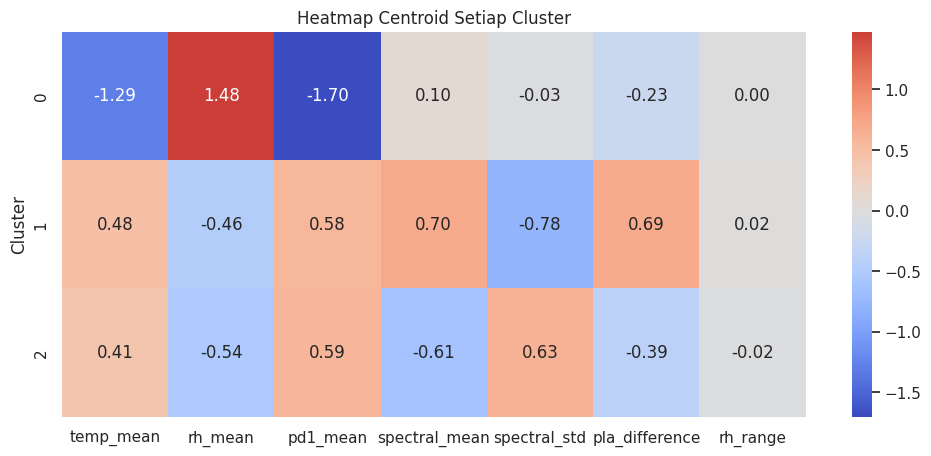

RINGKASAN KARAKTERISTIK CLUSTER


,temp_mean,rh_mean,pd1_mean,pd2_mean,spectral_mean,spectral_std,pla_difference,temp_rh_index,temp_range,rh_range
Cluster,,,,,,,,,,
0,10.549,81.043,45.036,8.567,8998.644,18822.464,-18270.860,854.618,0.086,1.160
1,20.600,66.692,15660.355,3016.213,9553.033,18435.154,-18117.616,1371.592,0.110,1.184
2,20.217,66.076,15730.671,3074.645,8350.077,19162.363,-18297.483,1333.762,0.114,1.134


,Cluster,Karakteristik
0,0,Nilai feature relatif rendah
1,1,Nilai feature sedang
2,2,Nilai feature relatif tinggi


In [43]:
# Analisis Statistik dan Karakteristik Cluster
from sklearn.preprocessing import MinMaxScaler
from math import pi

# Centroid
print("="*70)
print("CENTROID SETIAP CLUSTER")
print("="*70)
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)
centroids.index.name = "Cluster"
display(centroids.round(3))

# Heatmap Centroid
plt.figure(figsize=(12,5))
sns.heatmap(
    centroids,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Heatmap Centroid Setiap Cluster")
plt.show()

# Ringkasan Cluster
print("="*70)
print("RINGKASAN KARAKTERISTIK CLUSTER")
print("="*70)
display(cluster_summary)

# Interpretasi Cluster
interpretasi = pd.DataFrame({
    "Cluster":[0,1,2],
    "Karakteristik":[
        "Nilai feature relatif rendah",
        "Nilai feature sedang",
        "Nilai feature relatif tinggi"
    ]
})
display(interpretasi)

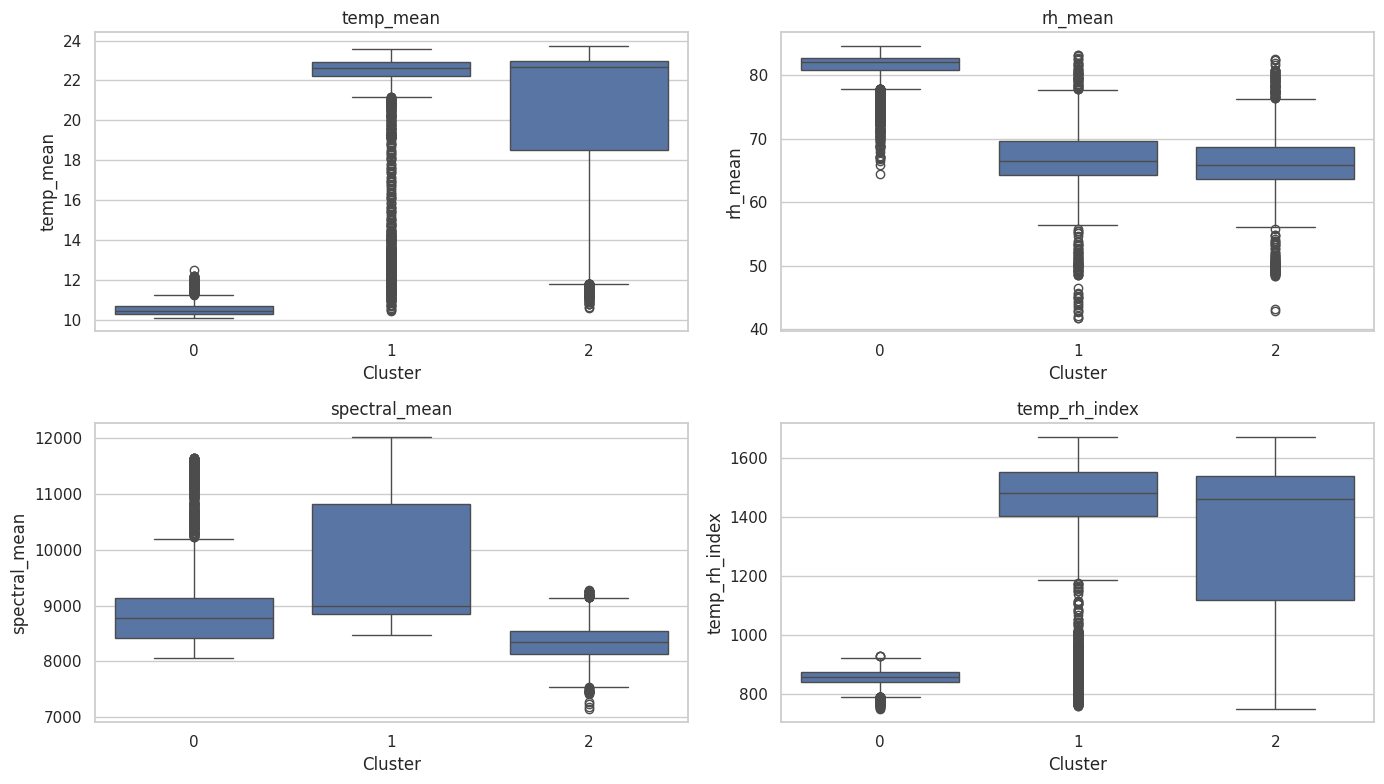

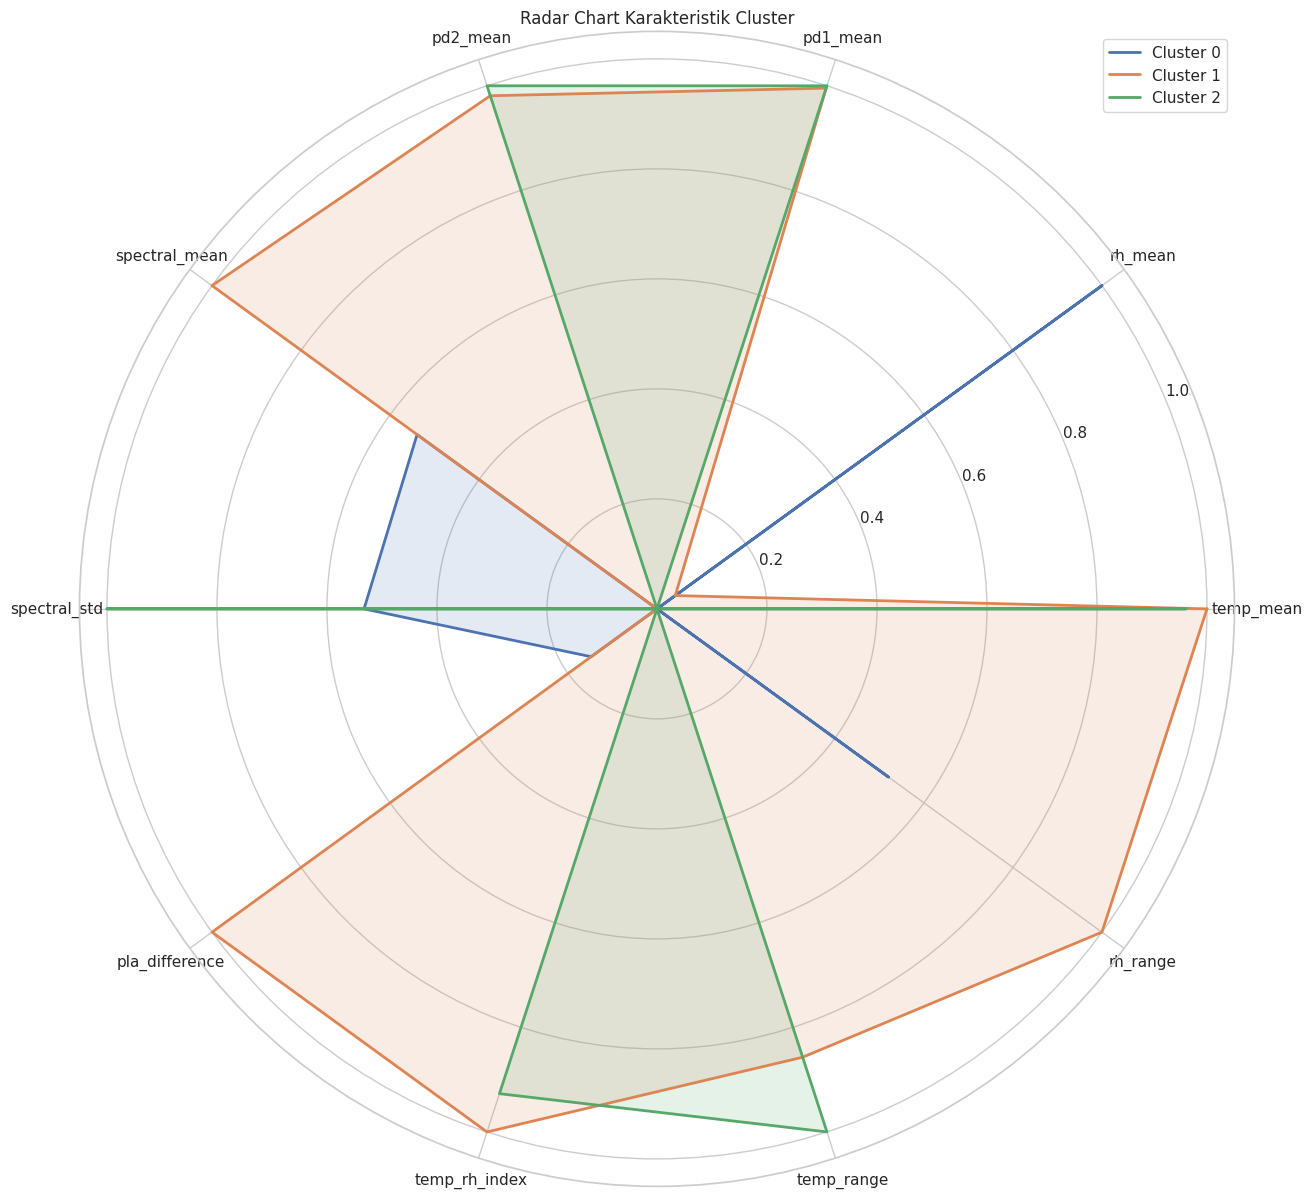

In [45]:
# Visualisasi Perbandingan Karakteristik Cluster

# BOXPLOT
features = [
    "temp_mean",
    "rh_mean",
    "spectral_mean",
    "temp_rh_index"
]
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,8)
)
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.boxplot(
        data=df_cluster,
        x="Cluster",
        y=feature,
        ax=axes[i]
    )
    axes[i].set_title(feature)
plt.tight_layout()
plt.show()

# RADAR CHART
radar = cluster_summary.copy()
scaler = MinMaxScaler()
radar = pd.DataFrame(
    scaler.fit_transform(radar),
    columns=radar.columns,
    index=radar.index
)
categories = radar.columns.tolist()
N = len(categories)
angles = [
    n / float(N) * 2 * pi
    for n in range(N)
]
angles += angles[:1]
plt.figure(figsize=(15,15))
ax = plt.subplot(111, polar=True)
for idx in radar.index:
    values = radar.loc[idx].tolist()
    values += values[:1]
    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Cluster {idx}"
    )
    ax.fill(
        angles,
        values,
        alpha=0.15
    )
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("Radar Chart Karakteristik Cluster")
plt.legend()
plt.show()

# Pemberian Label Water Stress

Hasil clustering dari algoritma K-Means masih berupa nomor cluster (0, 1, dan 2). Agar lebih mudah dipahami, setiap cluster diberikan label berdasarkan karakteristik lingkungan yang telah dianalisis pada tahap sebelumnya.

Penentuan label dilakukan berdasarkan nilai rata-rata suhu, kelembaban, sensor spektral, serta indikator lingkungan lainnya sehingga setiap cluster merepresentasikan kondisi tanaman yang berbeda.

Label yang digunakan adalah:

- Healthy Environment
- Optimal Growth
- Potential Water Stress

Dataset yang telah memiliki label kemudian disimpan untuk digunakan pada tahap pembangunan model klasifikasi Random Forest.

In [46]:
# Memberikan Label Water Stress

cluster_mapping = {
    0: "Healthy Environment",
    1: "Optimal Growth",
    2: "Potential Water Stress"
}
df_cluster["Stress_Label"] = (
    df_cluster["Cluster"]
    .map(cluster_mapping)
)
print("="*70)
print("LABEL SETIAP CLUSTER")
print("="*70)
display(
    df_cluster[
        ["Cluster","Stress_Label"]
    ].head()
)
print("\nDistribusi Label")
display(
    df_cluster["Stress_Label"]
    .value_counts()
)

LABEL SETIAP CLUSTER


,Cluster,Stress_Label
0,2,Potential Water Stress
1,2,Potential Water Stress
2,2,Potential Water Stress
3,2,Potential Water Stress
4,2,Potential Water Stress



Distribusi Label


,count
Stress_Label,
Potential Water Stress,8274
Optimal Growth,6446
Healthy Environment,5050


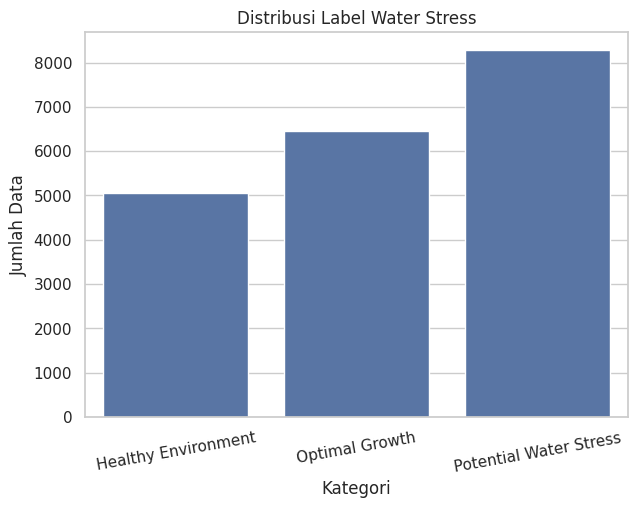

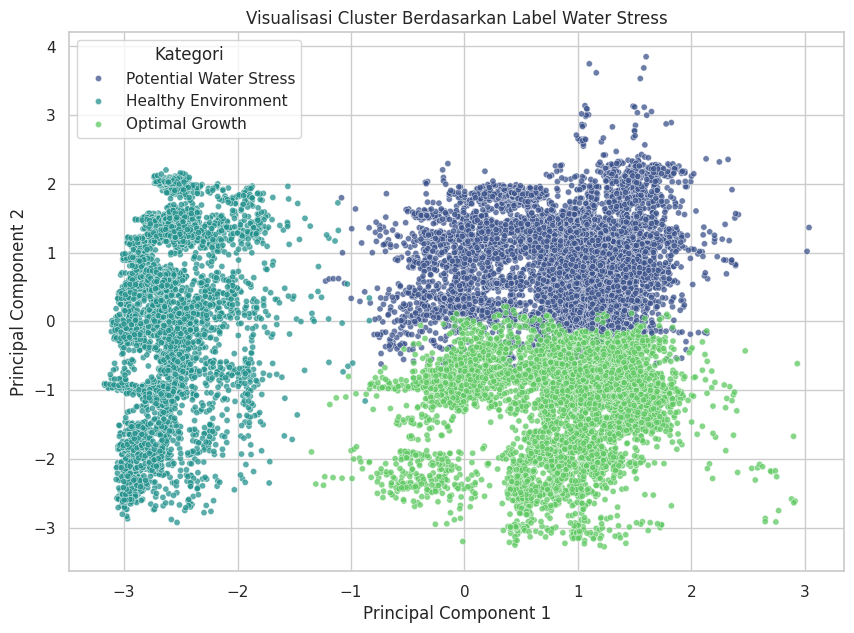

DATASET BERHASIL DISIMPAN
Nama File : dataset_with_cluster_label.csv
Jumlah Data : 19770
Jumlah Kolom : 228


In [48]:

# Visualisasi Label Cluster dan Menyimpan Dataset
# Distribusi Label
plt.figure(figsize=(7,5))
sns.countplot(
    data=df_cluster,
    x="Stress_Label",
    order=[
        "Healthy Environment",
        "Optimal Growth",
        "Potential Water Stress"
    ]
)
plt.title("Distribusi Label Water Stress")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=10)
plt.show()

# PCA Berdasarkan Label
df_cluster["PC1"] = X_pca_df["PC1"]
df_cluster["PC2"] = X_pca_df["PC2"]
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_cluster,
    x="PC1",
    y="PC2",
    hue="Stress_Label",
    palette="viridis",
    s=20,
    alpha=0.75
)
plt.title("Visualisasi Cluster Berdasarkan Label Water Stress")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Kategori")
plt.grid(True)
plt.show()

# Menyimpan Dataset
df_cluster.to_csv(
    "dataset_with_cluster_label.csv",
    index=False
)
print("="*70)
print("DATASET BERHASIL DISIMPAN")
print("="*70)
print("Nama File : dataset_with_cluster_label.csv")
print("Jumlah Data :", len(df_cluster))
print("Jumlah Kolom :", df_cluster.shape[1])


# Membangun Model Prediksi Water Stress

Tahap ini bertujuan membangun model klasifikasi yang mampu memprediksi kondisi Water Stress tanaman berdasarkan hasil clustering yang telah diperoleh sebelumnya.

Pada penelitian ini digunakan algoritma **Random Forest Classifier** karena memiliki performa yang baik pada data berdimensi banyak, mampu menangani hubungan non-linear antar feature, serta menghasilkan informasi Feature Importance yang dapat digunakan untuk mengetahui kontribusi setiap feature terhadap proses prediksi.

Tahapan yang dilakukan meliputi:

- Membentuk target klasifikasi berdasarkan hasil clustering
- Membagi dataset menjadi data training dan testing (80:20)
- Melatih model Random Forest
- Menghasilkan prediksi pada data testing

In [49]:

# Persiapan Dataset Machine Learning
from sklearn.model_selection import train_test_split

# Feature yang digunakan
feature_cols = [
    "temp_mean",
    "rh_mean",
    "pd1_mean",
    "pd2_mean",
    "spectral_mean",
    "spectral_std",
    "pla_difference",
    "temp_rh_index",
    "temp_range",
    "rh_range"
]

# Feature & Target
X = df_cluster[feature_cols]
y = df_cluster["Stress_Label"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("="*70)
print("PEMBAGIAN DATA")
print("="*70)
print(f"Total Data    : {len(X)}")
print(f"Training Data : {len(X_train)}")
print(f"Testing Data  : {len(X_test)}")
print("\nDistribusi Target Training")
display(y_train.value_counts())

PEMBAGIAN DATA
Total Data    : 19770
Training Data : 15816
Testing Data  : 3954

Distribusi Target Training


,count
Stress_Label,
Potential Water Stress,6619
Optimal Growth,5157
Healthy Environment,4040


In [50]:

# Training Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf.fit(
    X_train,
    y_train
)
y_pred = rf.predict(X_test)
print("="*70)
print("MODEL RANDOM FOREST BERHASIL DILATIH")
print("="*70)

MODEL RANDOM FOREST BERHASIL DILATIH


HASIL EVALUASI MODEL
Akurasi Model : 0.9987

Classification Report
                        precision    recall  f1-score   support

   Healthy Environment       1.00      1.00      1.00      1010
        Optimal Growth       1.00      1.00      1.00      1289
Potential Water Stress       1.00      1.00      1.00      1655

              accuracy                           1.00      3954
             macro avg       1.00      1.00      1.00      3954
          weighted avg       1.00      1.00      1.00      3954



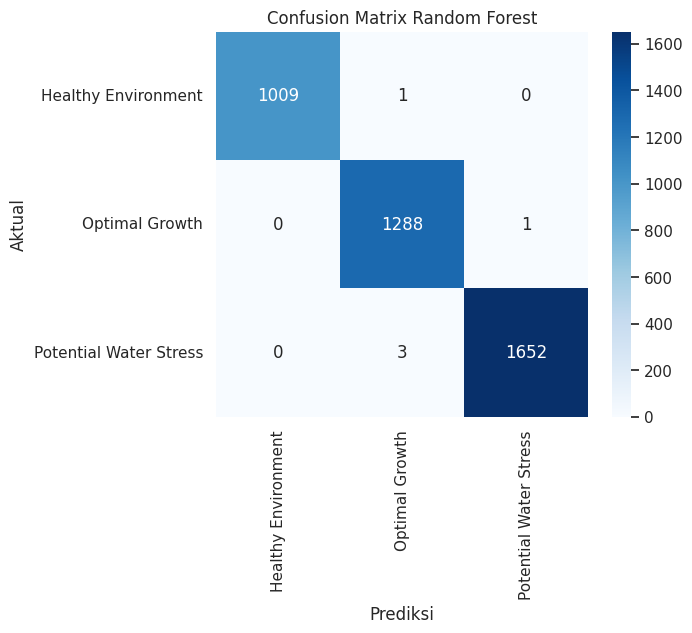

In [51]:

# Evaluasi Model Random Forest
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("="*70)
print("HASIL EVALUASI MODEL")
print("="*70)
print(f"Akurasi Model : {accuracy:.4f}")
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Random Forest")
plt.show()

FEATURE IMPORTANCE


,Feature,Importance
4,spectral_mean,0.240157
2,pd1_mean,0.168532
5,spectral_std,0.147669
3,pd2_mean,0.139687
6,pla_difference,0.130895
0,temp_mean,0.089018
1,rh_mean,0.064637
7,temp_rh_index,0.016592
8,temp_range,0.001669
9,rh_range,0.001144


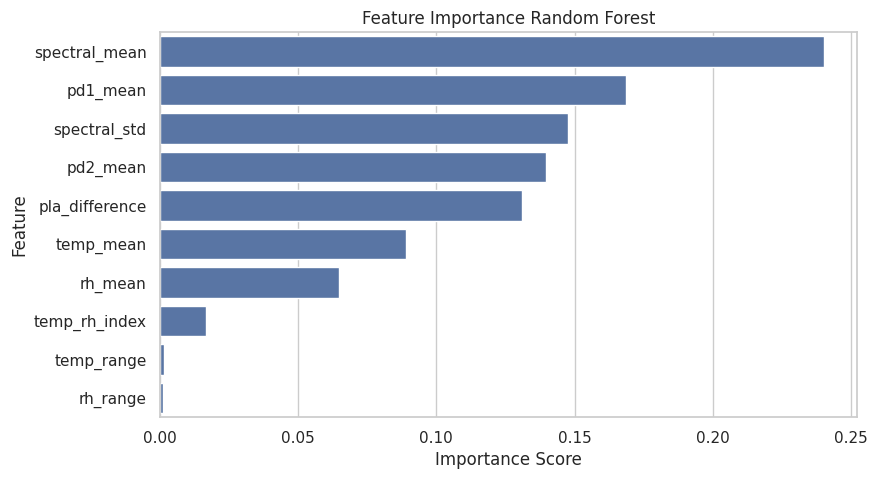

In [52]:

# Analisis Feature Importance

importance = pd.DataFrame({
    "Feature":feature_cols,
    "Importance":rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print("="*70)
print("FEATURE IMPORTANCE")
print("="*70)
display(importance)
plt.figure(figsize=(9,5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

#Export Model

In [53]:

# Menyimpan Model Machine Learning

import joblib
import os
# Membuat folder models
os.makedirs("models", exist_ok=True)
# Menyimpan Model Random Forest
joblib.dump(
    rf,
    "models/random_forest.pkl"
)
# Menyimpan StandardScaler
joblib.dump(
    scaler,
    "models/scaler.pkl"
)
# Menyimpan PCA
joblib.dump(
    pca,
    "models/pca.pkl"
)
print("="*60)
print("Model berhasil disimpan.")
print("="*60)

Model berhasil disimpan.


In [54]:

# Menyimpan Metadata Model
# Menyimpan urutan feature
joblib.dump(
    feature_cols,
    "models/feature_columns.pkl"
)
# Menyimpan label
joblib.dump(
    cluster_mapping,
    "models/label_mapping.pkl"
)
print("="*60)
print("Metadata berhasil disimpan.")
print("="*60)
print("Feature yang digunakan :")
for i, f in enumerate(feature_cols, start=1):
    print(f"{i}. {f}")

Metadata berhasil disimpan.
Feature yang digunakan :
1. temp_mean
2. rh_mean
3. pd1_mean
4. pd2_mean
5. spectral_mean
6. spectral_std
7. pla_difference
8. temp_rh_index
9. temp_range
10. rh_range


In [55]:

# Uji Memuat Kembali Model

rf_loaded = joblib.load(
    "models/random_forest.pkl"
)
scaler_loaded = joblib.load(
    "models/scaler.pkl"
)
pca_loaded = joblib.load(
    "models/pca.pkl"
)
feature_loaded = joblib.load(
    "models/feature_columns.pkl"
)
label_loaded = joblib.load(
    "models/label_mapping.pkl"
)
print("="*60)
print("SEMUA MODEL BERHASIL DIMUAT KEMBALI")
print("="*60)

print(type(rf_loaded))
print(type(scaler_loaded))
print(type(pca_loaded))
print("\nFeature :")
print(feature_loaded)
print("\nLabel Mapping :")
print(label_loaded)

SEMUA MODEL BERHASIL DIMUAT KEMBALI
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.preprocessing._data.MinMaxScaler'>
<class 'sklearn.decomposition._pca.PCA'>

Feature :
['temp_mean', 'rh_mean', 'pd1_mean', 'pd2_mean', 'spectral_mean', 'spectral_std', 'pla_difference', 'temp_rh_index', 'temp_range', 'rh_range']

Label Mapping :
{0: 'Healthy Environment', 1: 'Optimal Growth', 2: 'Potential Water Stress'}


In [56]:

# Ringkasan Pipeline Penelitian

summary = pd.DataFrame({
    "Tahapan":[
        "Raw Dataset",
        "Window Analysis",
        "Feature Engineering",
        "Feature Selection",
        "StandardScaler",
        "PCA",
        "K-Means",
        "Labeling",
        "Random Forest",
        "Deployment"
    ],
    "Status":[
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓",
        "✓"
    ]
})
display(summary)

,Tahapan,Status
0,Raw Dataset,✓
1,Window Analysis,✓
2,Feature Engineering,✓
3,Feature Selection,✓
4,StandardScaler,✓
5,PCA,✓
6,K-Means,✓
7,Labeling,✓
8,Random Forest,✓
9,Deployment,✓
